> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

# Mars PINN Forward Problem: Optimisation Journey

## Problem Setup

Modelling Martian subsurface temperatures using InSight HP³ mission data (Spohn et al. 2024). The PINN solves the 1D heat diffusion equation:

$$\frac{\partial u}{\partial t} = \kappa \frac{\partial^2 u}{\partial x^2}$$

- **Domain:** x ∈ [0, 0.4] m depth, t ∈ [0, 88775.244] s (one Martian sol)
- **Data:** RAD radiometer (surface, x = 0), TEM-A mole sensors (x = 0.094 m)
- **Fixed parameter:** κ = 3.93 × 10⁻⁸ m²/s
- **Bottom BC:** Fixed at mean temperature 225.6 K (x = 0.4 m)

---

## Baseline Configuration

| Setting | Value |
|---------|-------|
| Architecture | 3 layers × 64 neurons, tanh activation |
| Input dimension | 2 (normalised t, x) |
| Collocation points | 10,000 |
| Loss weights | BC × 1, Physics × 1, Data × 50 |
| Optimiser | Adam, constant lr = 1e-3 |
| Iterations | 80,000 |

**Baseline result:** Loss = 0.002070, RMSE = 0.33 K

---

## Approach 1: Fourier Feature Embeddings

**Hypothesis:** The physics loss plateau was caused by spectral bias — standard MLPs with tanh activations struggle to represent high-frequency components, and this compounds in second-order derivatives needed for the heat equation residual.

**Implementation:** Added sin(2πft) and cos(2πft) for integer frequencies f = 1, 2, ..., N to the time input only (depth has exponential decay character, not oscillatory). Raw t and x still included.

| Frequencies | Input dim | Loss | RMSE |
|-------------|-----------|------|------|
| 5 (f = 1–5) | 12 | 0.003556 | 0.36 K |
| 2 (f = 1–2) | 6 | 0.003666 | 0.39 K |
| 1 (f = 1) | 4 | 0.003488 | 0.38 K |

**Conclusion:** Fourier features **did not help**. The subsurface signal at 9.4 cm depth is already heavily damped by the thermal skin depth (~3.3 cm for diurnal). The temperature wave is smooth enough that tanh handles it without spectral assistance. The added input complexity made optimisation harder without providing useful representational benefit.

**Key lesson:** Fourier features help when the *target signal* contains high-frequency content the network can't capture. At depth, the soil acts as a low-pass filter — the signal is already smooth.

---

## Approach 2: Learning Rate Schedules

**Hypothesis:** The loss was still declining at 80k iterations; the optimizer needed either more time or a gentler step size to converge further.

### Piecewise constant schedules

| Schedule | Total iterations | Loss | RMSE |
|----------|-----------------|------|------|
| Constant 1e-3 | 80,000 | 0.002070 | 0.33 K |
| 1e-3 → 1e-4 at 60k | 80,000 | 0.002409 | 0.34 K |
| 1e-3 (80k) → 1e-4 (40k) | 120,000 | 0.001523 | 0.29 K |
| 1e-3 (80k) → 1e-4 (80k) | 160,000 | 0.001279 | 0.28 K |
| Constant 1e-3 | 160,000 | oscillates 0.0012–0.0022 | 0.31 K |
| 1e-3 (120k) → 1e-4 (80k) | 200,000 | 0.001081 | 0.26 K |

**Conclusion:** Learning rate schedules **helped meaningfully**. The constant 1e-3 rate finds good minima but overshoots them — visible as oscillating loss values. Decaying to 1e-4 allows the optimizer to settle. The best strategy was a long exploration phase at 1e-3 followed by a long settling phase at 1e-4.

**Key observation:** At 160k with constant lr, the loss *bounced* between 0.0012 and 0.0022 — proving the optimizer was finding but not staying in good minima. The decay to 1e-4 captured these.

**Key lesson:** Very low learning rates (1e-5) were unproductive at this loss scale. The landscape was still too coarse for such small steps.

---

## Approach 3: Increased Network Capacity

**Hypothesis:** The 3×64 network (~8,500 parameters) had insufficient capacity to represent the solution.

| Architecture | Parameters | Loss | RMSE | Depth profiles |
|-------------|------------|------|------|----------------|
| 3 × 64 | ~8,500 | 0.001081 | 0.26 K | Unphysical (swings ±100 K) |
| 4 × 128 | ~50,000 | 0.000026 | 0.05 K | Extremely unphysical (swings ±400 K) |
| 4 × 128 + scheduler | ~50,000 | 0.000034 | 0.006 K | Still unphysical |

**Conclusion:** The 4×128 network achieved spectacular data fit (0.006 K RMSE at mole depth) but **completely failed physically**. Temperature vs depth profiles showed swings to -400 K at 30 cm depth — physically impossible. The network memorised the measurement points while producing nonsense in data-sparse regions.

**Key lesson:** Low RMSE at measurement locations does not mean the model is correct. Depth profile validation is essential. A bigger network requires stronger physics constraints to prevent overfitting.

---

## Approach 4: Loss Weight Rebalancing

**Hypothesis:** The data loss (weight 50) was overpowering the physics loss, causing the network to fit data at the expense of PDE compliance.

| Weights (BC, Physics, Data) | Architecture | Loss | RMSE | Depth profiles |
|----------------------------|-------------|------|------|----------------|
| 1, 1, 50 | 4 × 128 | 0.000026 | 0.05 K | Catastrophic |
| 1, 1, 10 | 4 × 128 | 0.000034 | 0.15 K | Still bad |
| 1, 10, 10 | 3 × 64 | — | 2.07 K | Slightly better, still wild |

**Conclusion:** Rebalancing alone **did not fix depth profiles**. Even with high physics weights, the depth behaviour remained unphysical. This pointed toward a more fundamental issue in how the physics was being enforced.

---

## Approach 5: Increased Collocation Points

**Hypothesis:** 10,000 physics points were insufficient to constrain a large network across the full domain.

| Collocation points | Architecture | Weights | RMSE | Depth profiles |
|-------------------|-------------|---------|------|----------------|
| 10,000 | 4 × 128 | 1, 10, 10 | 0.88 K | Catastrophic (worse) |
| 50,000 | 4 × 128 | 1, 10, 10 | — | Even worse |

**Conclusion:** More collocation points **made things worse**. The additional computational cost (50 min vs 10 min) produced no improvement. The problem was not sampling density.

---

## Approach 6: PDE Residual Rescaling (Breakthrough)

**Diagnosis:** The normalised diffusivity κ_eff ≈ 0.022 was causing a fundamental imbalance in the physics residual:

$$r = \frac{\partial u}{\partial \hat{t}} - 0.022 \cdot \frac{\partial^2 u}{\partial \hat{x}^2}$$

The second spatial derivative was being multiplied by 0.022 before entering the loss, meaning the network could have massive spatial curvature (d²u/dx² = 100) and the physics loss barely noticed (contribution of only 2.2). The physics loss was effectively learning "du/dt ≈ 0" while **ignoring spatial smoothness**.

**Fix:** Divide the PDE by κ_eff so both terms contribute equally:

$$\frac{1}{\kappa_{\text{eff}}} \frac{\partial u}{\partial \hat{t}} - \frac{\partial^2 u}{\partial \hat{x}^2} = 0$$

Code change: `return du_dt / kappa_eff - d2u_dx2` instead of `return du_dt - kappa_eff * d2u_dx2`

| Config | RMSE | Depth profiles |
|--------|------|----------------|
| Before rescaling (any config) | various | All unphysical, ±100–400 K swings |
| After rescaling, 3×64, data×200 | 1.47 K | Physical: 200–260 K range, converging to 225.6 K |
| After rescaling, 4×64, data×200 | 1.44 K | Similar, slightly better |

**Conclusion:** PDE rescaling was the **single most important fix** for physical correctness. All configurations before rescaling produced unphysical depth profiles. After rescaling, the temperature field behaved physically at all depths.

**Key lesson:** When normalising inputs in PINNs, check whether the effective PDE coefficients create imbalanced residuals. A small coefficient on d²u/dx² means the network can create large spatial oscillations at negligible physics loss cost. Rescaling the PDE to balance terms is essential.

---

## Approach 7: Additional Network Depth (Post-Rescaling)

| Architecture | RMSE | Depth profiles | Dominant loss |
|-------------|------|----------------|---------------|
| 3 × 64 | 1.47 K | Physical | BC: 0.025 |
| 4 × 64 | 1.44 K | Physical | BC: 0.025 |

**Conclusion:** Adding a fourth layer provided minimal improvement. The bottleneck is now the BC loss (surface temperature matching), not network capacity.

---

## Final State and Diagnosis

**Best physically-valid result:** RMSE ≈ 1.44 K with rescaled PDE, 4×64 network, data weight 200.

**Best data-fit result (unphysical):** RMSE ≈ 0.006 K with 4×128 network, original PDE, but catastrophically wrong depth profiles.

The remaining error in the physically-valid model shows a **clean sinusoidal pattern** — consistent phase lag and amplitude mismatch at the mole depth. This signature indicates the fixed thermal diffusivity κ = 3.93 × 10⁻⁸ m²/s is not exactly correct for this depth and timescale. No amount of network tuning can fix this because the network is now correctly solving the heat equation — just with the wrong κ.

**Untried approaches:**
- L-BFGS as a second-stage optimizer (standard in PINN literature, could help 10–15%)
- Residual-adaptive resampling of collocation points
- Sinusoidal activation functions (SIREN)

**Natural next step:** Inverse problem — let the PINN learn κ from the data rather than fixing it, which would directly address the diagnosed phase/amplitude mismatch.

---

## Key Takeaways

1. **Always validate physics, not just data fit.** The 0.006 K RMSE result was meaningless because the depth profiles were catastrophically wrong. Depth profile plots should be the primary diagnostic.

2. **PDE coefficient scaling is critical.** A small κ_eff made the physics loss blind to spatial oscillations. Rescaling the PDE to balance terms was the most impactful single change.

3. **Network capacity is a double-edged sword.** Bigger networks fit data better but require proportionally stronger physics constraints to prevent memorisation in data-sparse regions.

4. **Fourier features aren't always useful.** When the target signal is already smooth (as with subsurface temperatures filtered by the thermal skin depth), Fourier features add complexity without benefit.

5. **Change one variable at a time.** Multiple simultaneous changes made diagnosis impossible. The most progress came from isolated experiments.

6. **Structured residual errors have physical meaning.** A sinusoidal error pattern at the mole depth indicates a wrong diffusivity parameter, not a network limitation — pointing naturally toward the inverse problem.

# Large Network (4 x 128) + 50k physics points

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (50,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (50000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (50000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
kappa_eff = kappa * (t_max - t_min) / ((x_max - x_min)**2)  # Effective diffusivity in normalized space

"""
#Transform inputs to Fourier features
def fourier_features(t, x):
    features = [t]
    for k in range(1, 2):  # k=1 
        features.append(jnp.sin( 2*jnp.pi*k * t))
        features.append(jnp.cos(2*jnp.pi*k * t))
    features.append(x)
    return jnp.stack(features, axis=-1)  # Shape (batch_size, 4)
"""

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.
    
    Args:
        layer_sizes: List of layer sizes, 
        key: JAX random key for initialization
        
    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))
    
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        
        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])
        
        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })
    
    return params


def network(params, x):
    """
    Forward pass through the network.
    
    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        
    Returns:
        Output array, shape (batch_size, output_dim)
    """

    #x = fourier_features(x[:, 0], x[:, 1])  # Convert (t, x) to Fourier features (batch_size, 12)

    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)
    
    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    
    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, kappa_eff):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]
    
    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    return du_dt - kappa_eff * d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params and kappa_eff fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 128, 128, 128, 128, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
#schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=40000, alpha=1e-5)

schedule = optax.piecewise_constant_schedule(init_value=1e-3, boundaries_and_scales={120000: 0.1})
optimizer = optax.adam(schedule)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, kappa_eff, t_data, x_data, u_data):

    def loss_fn(params):
        
        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)
        
        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params, 
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel(), # (10000,) not (10000, 1)
                                                kappa_eff)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)
        
        return  bc_loss + physics_loss * 10 + data_loss * 10, (bc_loss, physics_loss, data_loss)
    
        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 200000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        kappa_eff,
        t_data, x_data, u_data
    )
    
    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)

    
    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")





Iteration 1000/200000, Loss: 0.046957
Iteration 2000/200000, Loss: 0.023359
Iteration 3000/200000, Loss: 0.010888
Iteration 4000/200000, Loss: 0.008742
Iteration 5000/200000, Loss: 0.007546
Iteration 6000/200000, Loss: 0.005636
Iteration 7000/200000, Loss: 0.006154
Iteration 8000/200000, Loss: 0.005295
Iteration 9000/200000, Loss: 0.005069
Iteration 10000/200000, Loss: 0.005073
Iteration 11000/200000, Loss: 0.004842
Iteration 12000/200000, Loss: 0.004841
Iteration 13000/200000, Loss: 0.005081
Iteration 14000/200000, Loss: 0.007191
Iteration 15000/200000, Loss: 0.004778
Iteration 16000/200000, Loss: 0.004970
Iteration 17000/200000, Loss: 0.005736
Iteration 18000/200000, Loss: 0.004892
Iteration 19000/200000, Loss: 0.004930
Iteration 20000/200000, Loss: 0.004528
Iteration 21000/200000, Loss: 0.004442
Iteration 22000/200000, Loss: 0.004561
Iteration 23000/200000, Loss: 0.004331
Iteration 24000/200000, Loss: 0.004778
Iteration 25000/200000, Loss: 0.004421
Iteration 26000/200000, Loss: 0.00

In [19]:
print("-------Final losses------")

print("Final Loss:", losses[-1])
print("Data loss:", losses_data[-1])
print("Physics loss:", losses_phys[-1])
print("Boundary loss:", losses_bc[-1])

-------Final losses------
Final Loss: 0.00077855616
Data loss: 5.8348567e-05
Physics loss: 1.8426092e-05
Boundary loss: 1.0809581e-05


## Compare PINN with Data

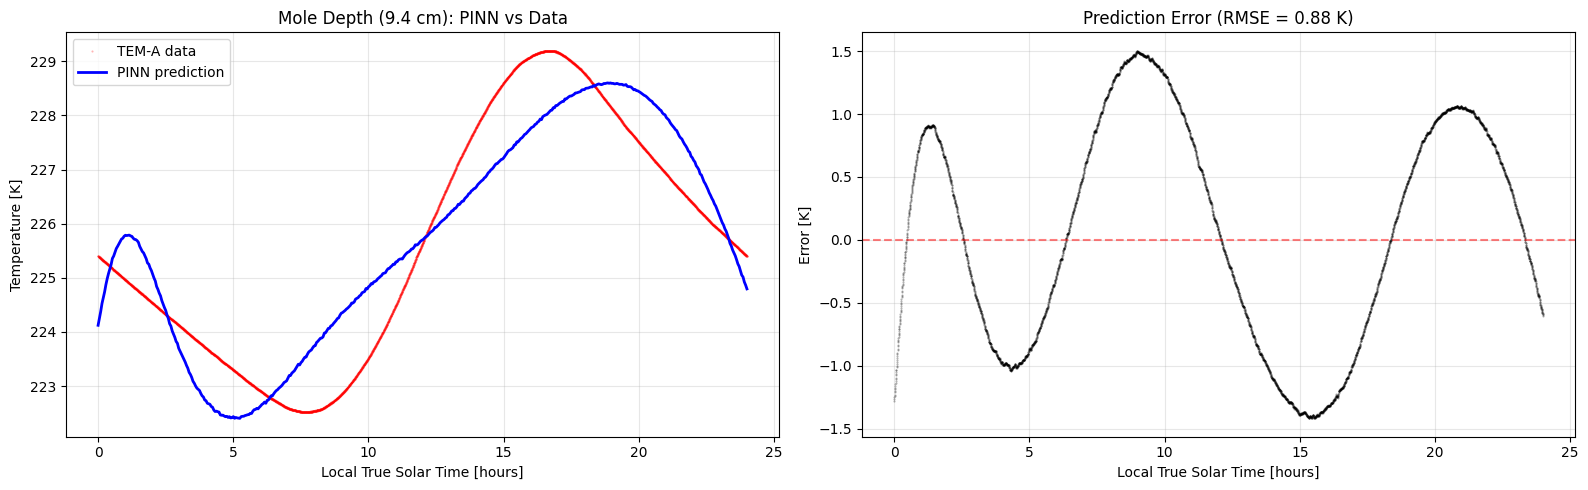

In [20]:
# ============================================================
# Plot: Network prediction vs TEM-A data at mole depth
# ============================================================

# Create a dense time array at the mole depth (normalised)
t_plot = jnp.linspace(0, 1, 500).reshape(-1, 1)  # normalised time [0,1]
x_plot = jnp.ones((500, 1)) * normalize_x(mole_depth)  # normalised mole depth

# Network prediction (normalised)
tx_plot = jnp.concatenate([t_plot, x_plot], axis=1)
u_pred_norm = network(params, tx_plot)

# Convert back to physical units
t_plot_hours = np.array(t_plot.ravel()) * 24  # back to LTST hours
u_pred_K = np.array(unnormalize_u(u_pred_norm.ravel()))  # back to Kelvin

# Also convert mole data back to hours for comparison
t_mole_hours = np.array(ltst_mole) * 24 / sol_seconds * (24/24)  
# Actually ltst_mole is already in seconds (converted earlier), so:
t_mole_hours = np.array(ltst_mole) / sol_seconds * 24  # seconds -> LTST hours
u_mole_K = np.array(temp_mole)  # already in Kelvin

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overlay prediction and data
ax1 = axes[0]
ax1.plot(t_mole_hours, u_mole_K, 'r.', markersize=1, alpha=0.3, label='TEM-A data')
ax1.plot(t_plot_hours, u_pred_K, 'b-', linewidth=2, label='PINN prediction')
ax1.set_xlabel('Local True Solar Time [hours]')
ax1.set_ylabel('Temperature [K]')
ax1.set_title('Mole Depth (9.4 cm): PINN vs Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: error (prediction - data) over time
# Interpolate prediction to data time points for direct comparison
u_pred_at_data = np.interp(t_mole_hours, t_plot_hours, u_pred_K)
error = u_pred_at_data - u_mole_K

ax2 = axes[1]
ax2.plot(t_mole_hours, error, 'k.', markersize=1, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.set_xlabel('Local True Solar Time [hours]')
ax2.set_ylabel('Error [K]')
ax2.set_title(f'Prediction Error (RMSE = {np.sqrt(np.mean(error**2)):.2f} K)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

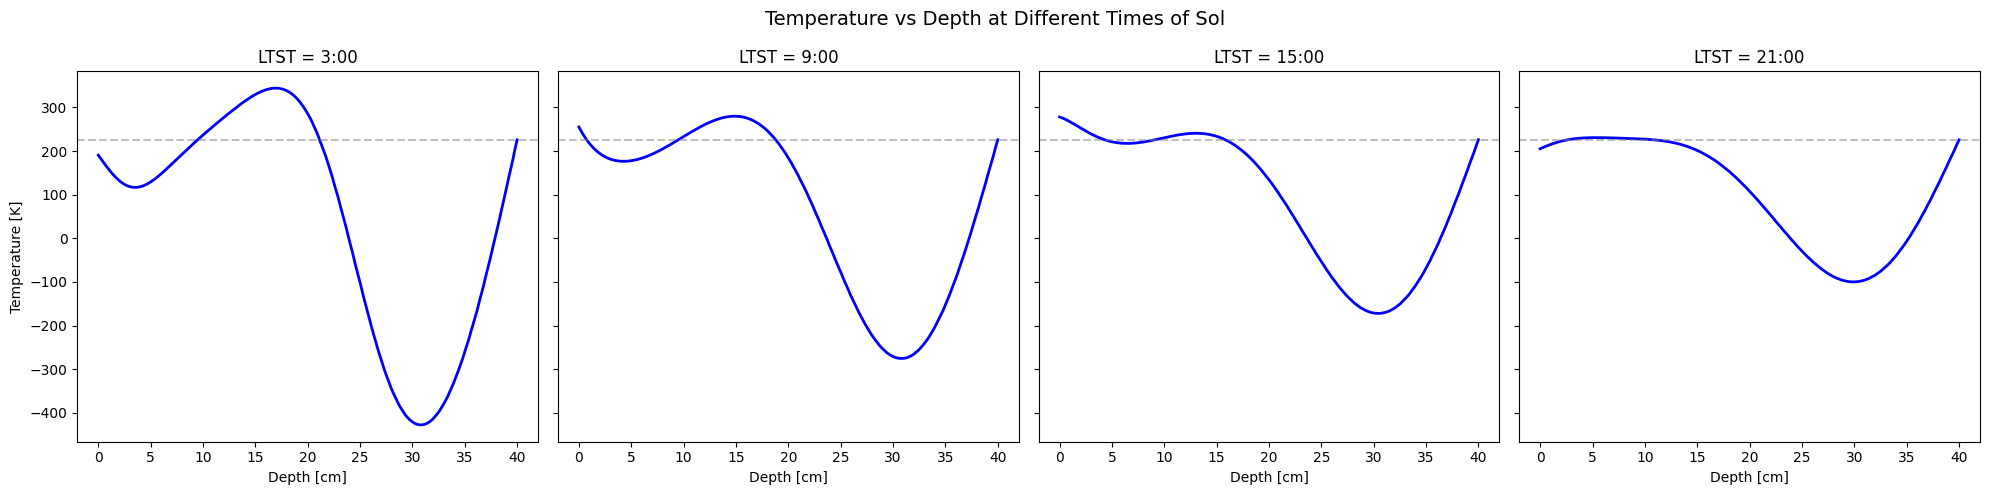

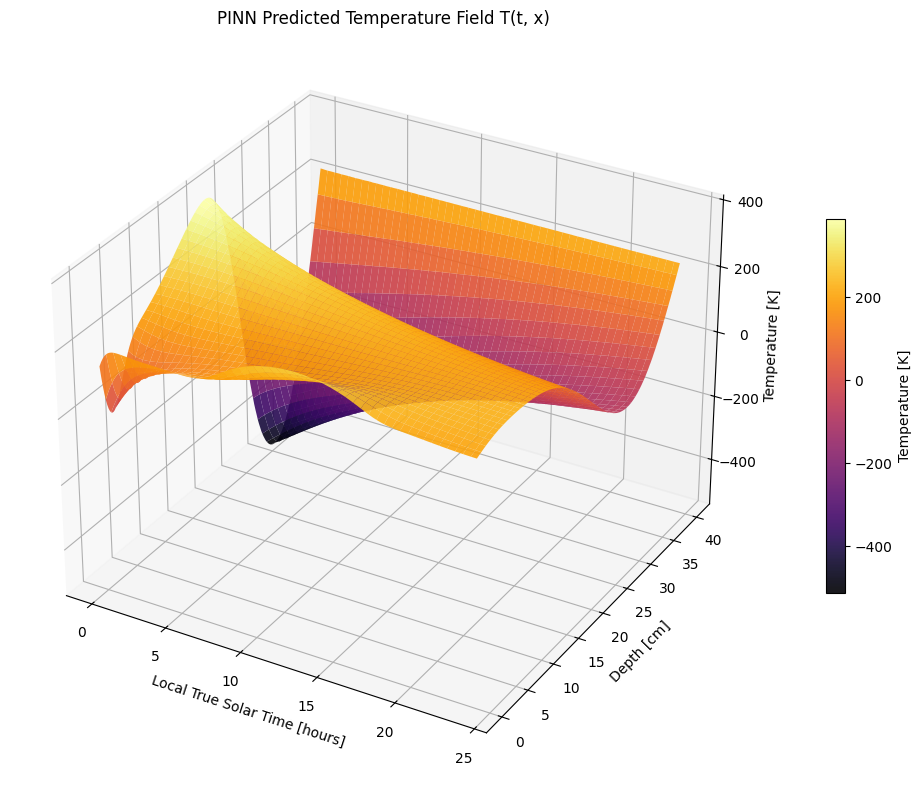

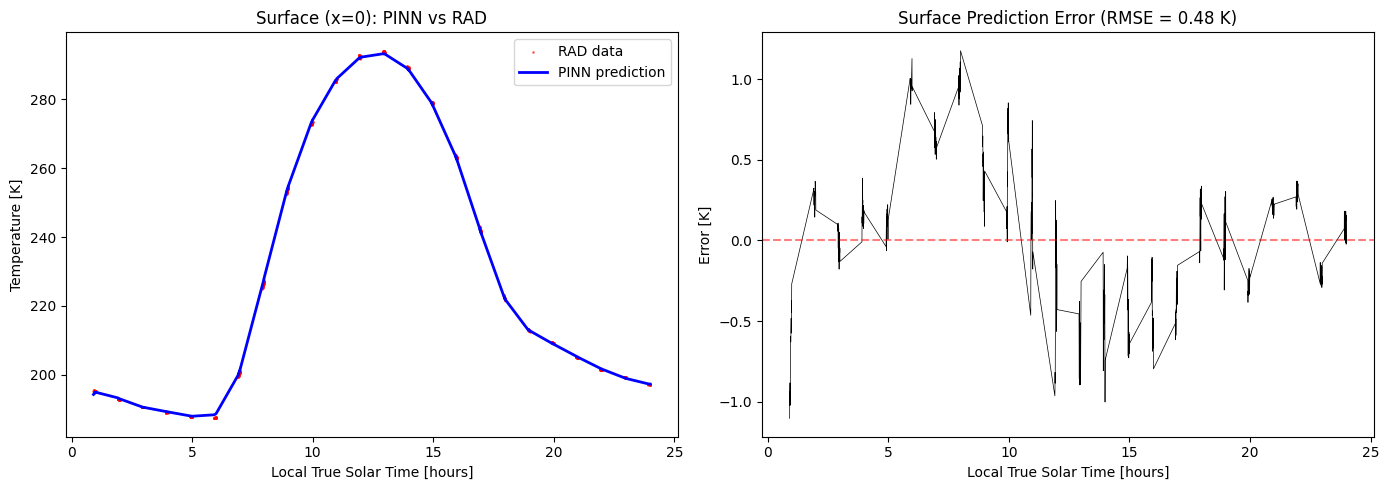

In [22]:
# Temperature vs Depth at four times of day
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

hours_to_plot = [3, 9, 15, 21]
depths = jnp.linspace(0, depth, 200)  # 0 to 0.4 m

for idx, hour in enumerate(hours_to_plot):
    t_sec = hour * sol_seconds / 24
    t_norm = normalize_t(t_sec)
    x_norm = normalize_x(depths)
    
    # Build input array
    t_input = jnp.ones_like(x_norm) * t_norm
    tx_input = jnp.stack([t_input, x_norm], axis=-1)
    
    # Predict
    u_pred_norm = network(params, tx_input)
    u_pred = unnormalize_u(u_pred_norm.ravel())
    
    axes[idx].plot(depths * 100, u_pred, 'b-', linewidth=2)  # depth in cm
    axes[idx].set_title(f'LTST = {hour}:00')
    axes[idx].set_xlabel('Depth [cm]')
    axes[idx].axhline(y=avg_bottom_temp, color='gray', linestyle='--', alpha=0.5, label='Bottom BC')
    
axes[0].set_ylabel('Temperature [K]')
plt.suptitle('Temperature vs Depth at Different Times of Sol', fontsize=14)
plt.tight_layout()
plt.show()


# 3D surface plot: T(t, x)
from mpl_toolkits.mplot3d import Axes3D

n_t, n_x = 200, 200
t_grid = jnp.linspace(0, 1, n_t)  # already normalized
x_grid = jnp.linspace(0, 1, n_x)  # already normalized

T_mesh, X_mesh = jnp.meshgrid(t_grid, x_grid)
tx_flat = jnp.stack([T_mesh.ravel(), X_mesh.ravel()], axis=-1)

u_pred_flat = network(params, tx_flat)
u_pred_grid = unnormalize_u(u_pred_flat.reshape(n_x, n_t))

# Convert axes back to physical units for plotting
t_hours = np.linspace(0, 24, n_t)
x_cm = np.linspace(0, depth * 100, n_x)
T_plot, X_plot = np.meshgrid(t_hours, x_cm)

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T_plot, X_plot, np.array(u_pred_grid), cmap='inferno', alpha=0.9)
ax.set_xlabel('Local True Solar Time [hours]')
ax.set_ylabel('Depth [cm]')
ax.set_zlabel('Temperature [K]')
ax.set_title('PINN Predicted Temperature Field T(t, x)')
fig.colorbar(surf, shrink=0.5, label='Temperature [K]')
plt.tight_layout()
plt.show()


# PINN vs RAD at surface (x=0)
t_surf_norm = normalize_t(jnp.array(ltst_surf))
x_surf_norm = jnp.zeros_like(t_surf_norm)
tx_surf = jnp.stack([t_surf_norm, x_surf_norm], axis=-1)

u_pred_surf = unnormalize_u(network(params, tx_surf).ravel())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ltst_hours_surf = [t * 24 / sol_seconds for t in ltst_surf]

axes[0].scatter(ltst_hours_surf, temp_surf, s=1, c='red', alpha=0.5, label='RAD data')
axes[0].plot(ltst_hours_surf, np.array(u_pred_surf), 'b-', linewidth=2, label='PINN prediction')
axes[0].set_xlabel('Local True Solar Time [hours]')
axes[0].set_ylabel('Temperature [K]')
axes[0].set_title('Surface (x=0): PINN vs RAD')
axes[0].legend()

# Error at surface
error_surf = np.array(u_pred_surf) - np.array(temp_surf)
axes[1].plot(ltst_hours_surf, error_surf, 'k-', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Local True Solar Time [hours]')
axes[1].set_ylabel('Error [K]')
rmse_surf = np.sqrt(np.mean(error_surf**2))
axes[1].set_title(f'Surface Prediction Error (RMSE = {rmse_surf:.2f} K)')

plt.tight_layout()
plt.show()

Network is very good at reducing data loss but results are highly unphysical as 700k temperature swings reaching -400k are not physically posible. In order to get the network to pay more attention to the physics loss we will try a smaller network again.

# Small Network (4 x 64) + 25k points

Im going back to a smaller network because the bigger network seems to be overfitting for the data points and not obeying the physics correctly.

In [23]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
kappa_eff = kappa * (t_max - t_min) / ((x_max - x_min)**2)  # Effective diffusivity in normalized space


# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.
    
    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization
        
    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))
    
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        
        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])
        
        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })
    
    return params


def network(params, x):
    """
    Forward pass through the network.
    
    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        
    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)
    
    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    
    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, kappa_eff):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]
    
    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params and kappa_eff fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, kappa_eff, t_data, x_data, u_data):

    def loss_fn(params):
        
        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)
        
        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params, 
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel(), # (10000,) not (10000, 1)
                                                kappa_eff)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)
        
        return  bc_loss + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)
    
        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 120000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        kappa_eff,
        t_data, x_data, u_data
    )
    
    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)

    
    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")





Iteration 1000/120000, Loss: 0.280873
Iteration 2000/120000, Loss: 0.149522
Iteration 3000/120000, Loss: 0.111301
Iteration 4000/120000, Loss: 0.102517
Iteration 5000/120000, Loss: 0.098534
Iteration 6000/120000, Loss: 0.096303
Iteration 7000/120000, Loss: 0.094248
Iteration 8000/120000, Loss: 0.093506
Iteration 9000/120000, Loss: 0.090830
Iteration 10000/120000, Loss: 0.110252
Iteration 11000/120000, Loss: 0.085814
Iteration 12000/120000, Loss: 0.092867
Iteration 13000/120000, Loss: 0.084103
Iteration 14000/120000, Loss: 0.094193
Iteration 15000/120000, Loss: 0.073420
Iteration 16000/120000, Loss: 0.068213
Iteration 17000/120000, Loss: 0.073411
Iteration 18000/120000, Loss: 0.070109
Iteration 19000/120000, Loss: 0.065984
Iteration 20000/120000, Loss: 0.069205
Iteration 21000/120000, Loss: 0.064866
Iteration 22000/120000, Loss: 0.064115
Iteration 23000/120000, Loss: 0.063633
Iteration 24000/120000, Loss: 0.063176
Iteration 25000/120000, Loss: 0.063634
Iteration 26000/120000, Loss: 0.06

## At which depth does the network struggle the most?

In [18]:
# Check physics residual at specific points
test_depths = [0.02, 0.05, 0.10, 0.20, 0.30]  # metres
test_hour = 12.0
t_norm_test = normalize_t(test_hour * sol_seconds / 24)

for d in test_depths:
    x_norm_test = normalize_x(d)
    residual = physics_residual_single(params, t_norm_test, x_norm_test, kappa_eff)
    print(f"Depth {d*100:.0f} cm: residual = {residual:.6f}")


print("-------Final losses------")
print("Final Loss:", losses[-1])
print("Data loss:", losses_data[-1])
print("Physics loss:", losses_phys[-1])
print("Boundary loss:", losses_bc[-1])

Depth 2 cm: residual = -0.030366
Depth 5 cm: residual = 0.006075
Depth 10 cm: residual = 0.078388
Depth 20 cm: residual = -0.012044
Depth 30 cm: residual = -0.020075
-------Final losses------
Final Loss: 0.056925897
Data loss: 0.00015733007
Physics loss: 0.0004942379
Boundary loss: 0.024965644


## Compare PINN with Data

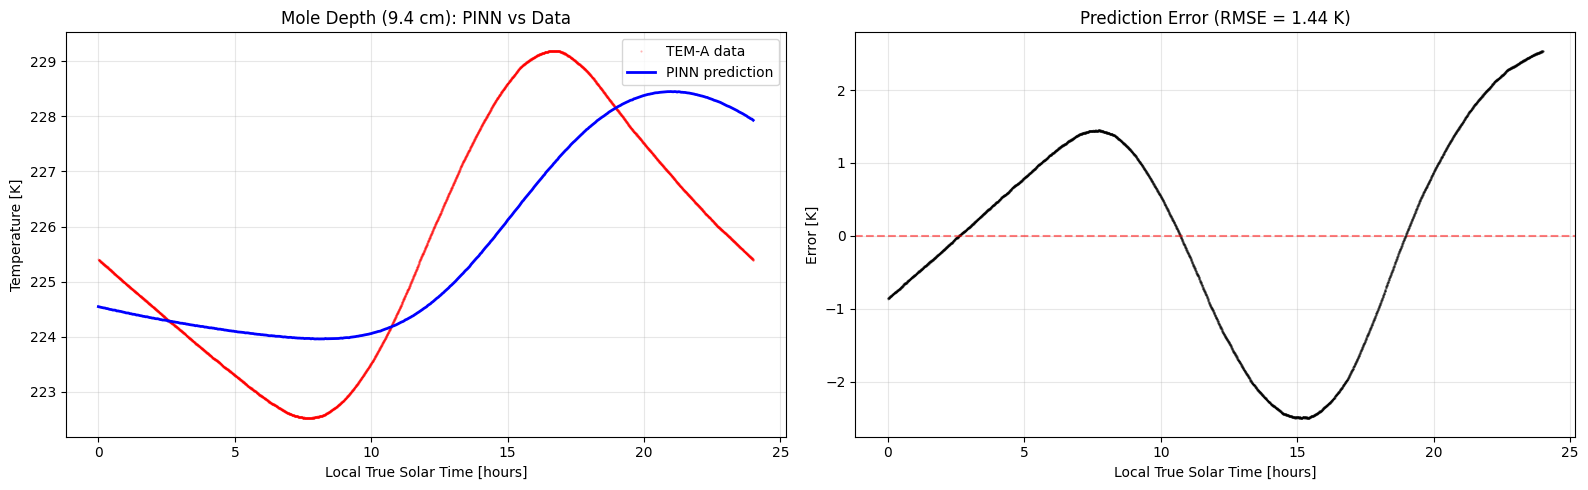

In [19]:
# ============================================================
# Plot: Network prediction vs TEM-A data at mole depth
# ============================================================

# Create a dense time array at the mole depth (normalised)
t_plot = jnp.linspace(0, 1, 500).reshape(-1, 1)  # normalised time [0,1]
x_plot = jnp.ones((500, 1)) * normalize_x(mole_depth)  # normalised mole depth

# Network prediction (normalised)
tx_plot = jnp.concatenate([t_plot, x_plot], axis=1)
u_pred_norm = network(params, tx_plot)

# Convert back to physical units
t_plot_hours = np.array(t_plot.ravel()) * 24  # back to LTST hours
u_pred_K = np.array(unnormalize_u(u_pred_norm.ravel()))  # back to Kelvin

# Also convert mole data back to hours for comparison
t_mole_hours = np.array(ltst_mole) * 24 / sol_seconds * (24/24)  
# Actually ltst_mole is already in seconds (converted earlier), so:
t_mole_hours = np.array(ltst_mole) / sol_seconds * 24  # seconds -> LTST hours
u_mole_K = np.array(temp_mole)  # already in Kelvin

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overlay prediction and data
ax1 = axes[0]
ax1.plot(t_mole_hours, u_mole_K, 'r.', markersize=1, alpha=0.3, label='TEM-A data')
ax1.plot(t_plot_hours, u_pred_K, 'b-', linewidth=2, label='PINN prediction')
ax1.set_xlabel('Local True Solar Time [hours]')
ax1.set_ylabel('Temperature [K]')
ax1.set_title('Mole Depth (9.4 cm): PINN vs Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: error (prediction - data) over time
# Interpolate prediction to data time points for direct comparison
u_pred_at_data = np.interp(t_mole_hours, t_plot_hours, u_pred_K)
error = u_pred_at_data - u_mole_K

ax2 = axes[1]
ax2.plot(t_mole_hours, error, 'k.', markersize=1, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.set_xlabel('Local True Solar Time [hours]')
ax2.set_ylabel('Error [K]')
ax2.set_title(f'Prediction Error (RMSE = {np.sqrt(np.mean(error**2)):.2f} K)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
print(kappa_eff)

0.021805419307499997


## Does the PINN follow the Physics?

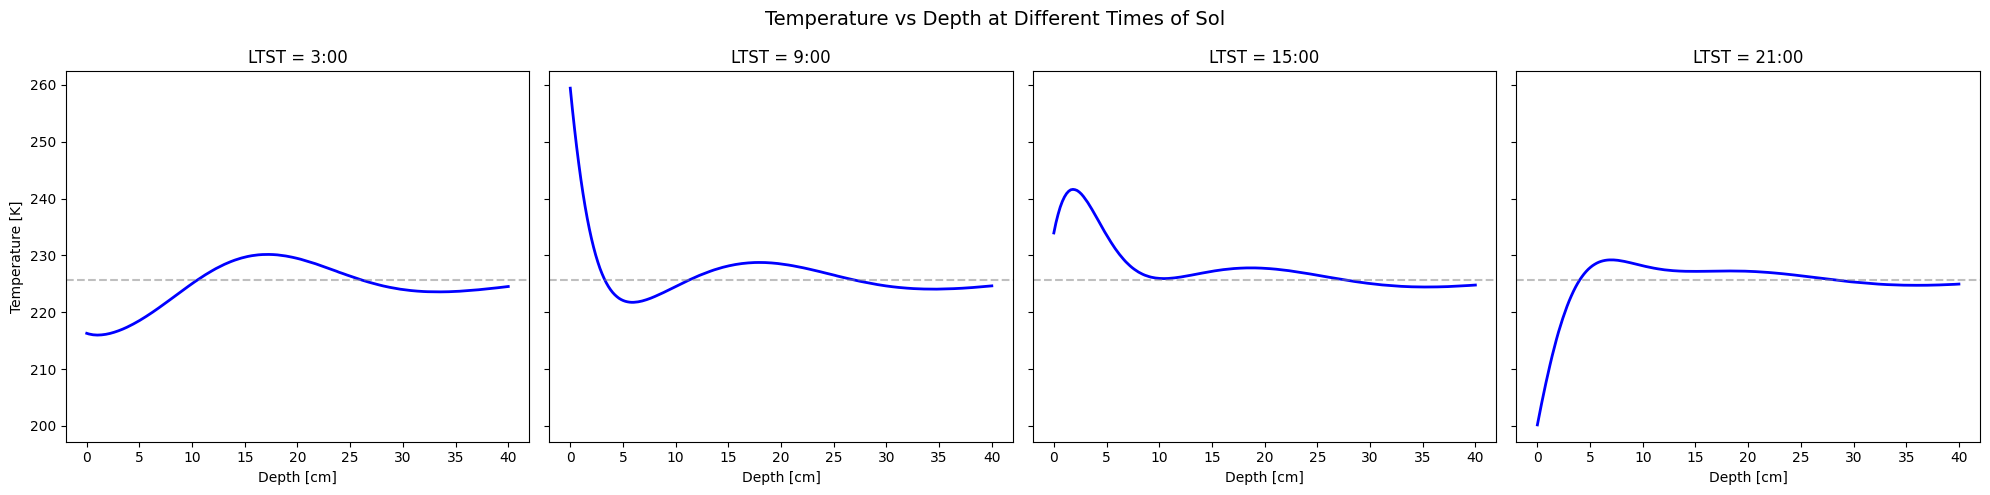

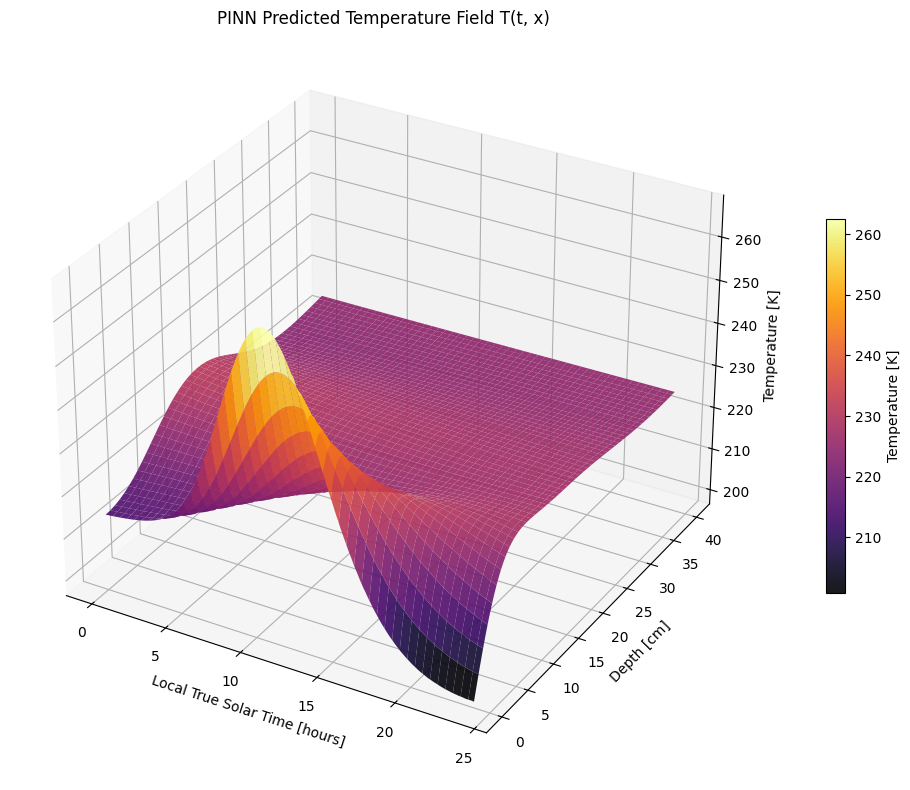

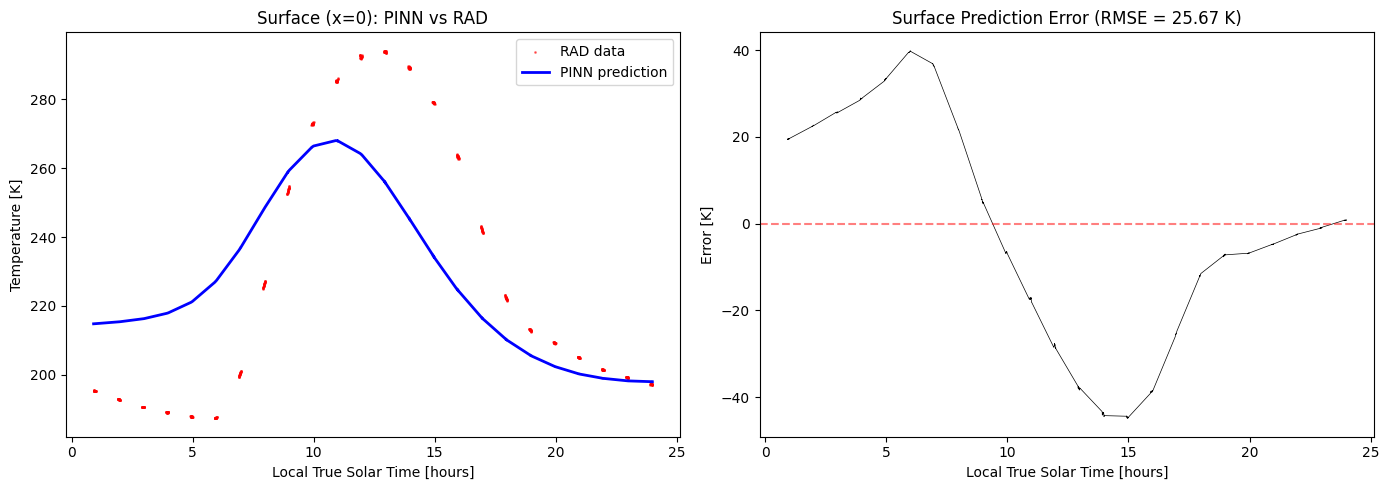

In [20]:
# Temperature vs Depth at four times of day
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

hours_to_plot = [3, 9, 15, 21]
depths = jnp.linspace(0, depth, 200)  # 0 to 0.4 m

for idx, hour in enumerate(hours_to_plot):
    t_sec = hour * sol_seconds / 24
    t_norm = normalize_t(t_sec)
    x_norm = normalize_x(depths)
    
    # Build input array
    t_input = jnp.ones_like(x_norm) * t_norm
    tx_input = jnp.stack([t_input, x_norm], axis=-1)
    
    # Predict
    u_pred_norm = network(params, tx_input)
    u_pred = unnormalize_u(u_pred_norm.ravel())
    
    axes[idx].plot(depths * 100, u_pred, 'b-', linewidth=2)  # depth in cm
    axes[idx].set_title(f'LTST = {hour}:00')
    axes[idx].set_xlabel('Depth [cm]')
    axes[idx].axhline(y=avg_bottom_temp, color='gray', linestyle='--', alpha=0.5, label='Bottom BC')
    
axes[0].set_ylabel('Temperature [K]')
plt.suptitle('Temperature vs Depth at Different Times of Sol', fontsize=14)
plt.tight_layout()
plt.show()


# 3D surface plot: T(t, x)
from mpl_toolkits.mplot3d import Axes3D

n_t, n_x = 200, 200
t_grid = jnp.linspace(0, 1, n_t)  # already normalized
x_grid = jnp.linspace(0, 1, n_x)  # already normalized

T_mesh, X_mesh = jnp.meshgrid(t_grid, x_grid)
tx_flat = jnp.stack([T_mesh.ravel(), X_mesh.ravel()], axis=-1)

u_pred_flat = network(params, tx_flat)
u_pred_grid = unnormalize_u(u_pred_flat.reshape(n_x, n_t))

# Convert axes back to physical units for plotting
t_hours = np.linspace(0, 24, n_t)
x_cm = np.linspace(0, depth * 100, n_x)
T_plot, X_plot = np.meshgrid(t_hours, x_cm)

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T_plot, X_plot, np.array(u_pred_grid), cmap='inferno', alpha=0.9)
ax.set_xlabel('Local True Solar Time [hours]')
ax.set_ylabel('Depth [cm]')
ax.set_zlabel('Temperature [K]')
ax.set_title('PINN Predicted Temperature Field T(t, x)')
fig.colorbar(surf, shrink=0.5, label='Temperature [K]')
plt.tight_layout()
plt.show()


# PINN vs RAD at surface (x=0)
t_surf_norm = normalize_t(jnp.array(ltst_surf))
x_surf_norm = jnp.zeros_like(t_surf_norm)
tx_surf = jnp.stack([t_surf_norm, x_surf_norm], axis=-1)

u_pred_surf = unnormalize_u(network(params, tx_surf).ravel())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ltst_hours_surf = [t * 24 / sol_seconds for t in ltst_surf]

axes[0].scatter(ltst_hours_surf, temp_surf, s=1, c='red', alpha=0.5, label='RAD data')
axes[0].plot(ltst_hours_surf, np.array(u_pred_surf), 'b-', linewidth=2, label='PINN prediction')
axes[0].set_xlabel('Local True Solar Time [hours]')
axes[0].set_ylabel('Temperature [K]')
axes[0].set_title('Surface (x=0): PINN vs RAD')
axes[0].legend()

# Error at surface
error_surf = np.array(u_pred_surf) - np.array(temp_surf)
axes[1].plot(ltst_hours_surf, error_surf, 'k-', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Local True Solar Time [hours]')
axes[1].set_ylabel('Error [K]')
rmse_surf = np.sqrt(np.mean(error_surf**2))
axes[1].set_title(f'Surface Prediction Error (RMSE = {rmse_surf:.2f} K)')

plt.tight_layout()
plt.show()